In [1]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2

In [2]:
import os
import copy

from functools import partial, reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import pingouin as pg
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

import matplotlib.patches as patches
import matplotlib.colors as mcolors

from sentence_transformers import SentenceTransformer

In [3]:
import utils as ut

In [4]:
pd.set_option('display.max_columns', 100)

In [5]:
# test run of the model for dev purposes, or full/final data set?
is_testcase = False

# Load Model Results from Disk

In [6]:
l_data_subset = ["full"]
l_rnd_seed = [1]
l_embed_dim_full = [35]
modeltype = "free_weights_no_scaling"
modelversion = "embeddings-decision-combined-data"
l_id_weights = ["separate"]
l_lmbda = [1e-07]

# was the flag shared or separate set?
is_shared_separate = True

# load results from model run
l_results_full = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim_full, modelversion=modelversion, modeltype=modeltype
)[0]

In [7]:
l_embed_dim_sh = [7]
l_rnd_seed = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
l_data_subset = ["first_half", "second_half"]

# load results from model run
l_results_splithalf = ut.load_ID_lowdim_id_weights(
    l_data_subset=l_data_subset, l_rnd_seed=l_rnd_seed, l_lmbda=l_lmbda, l_id_weights_type=l_id_weights,
    l_embed_dim=l_embed_dim_sh, modelversion=modelversion, modeltype=modeltype
)[0]


no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed10/data_subset_first_half
no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed10/data_subset_second_half
no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed11/data_subset_first_half
no results found in ./results/embeddings-decision-combined-data/modeltype_free_weights_no_scaling/7d/lmbda_1e-07/separate/seed11/data_subset_second_half


In [8]:
partial_sims = partial(ut.dimensional_similarities, l_results_splithalf)
l_cors = list(map(partial_sims, l_embed_dim_sh))

In [9]:
# reorder dimensions in the two halves according to the max. similar result
range_dims = range(l_embed_dim_sh[0], l_embed_dim_sh[0]+1)
partial_reorder = partial(ut.reorder_dimensions, l_results_splithalf)
l_max_sims = list(map(partial_reorder, l_embed_dim_sh))
dict_max_sims = dict(zip(range_dims, l_max_sims))

In [10]:
# extract idxs from seeds with maximally similar embedding dimensions
dict_idxs_use = ut.max_sim_dimensions_per_ndim(l_max_sims, range_dims)
dict_idxs_list_use = ut.max_sim_results_per_ndim(dict_idxs_use, dict_max_sims, range_dims)

In [11]:
l_keys = list(dict_idxs_use.keys())
dict_cors = {int(f'{l_keys[i]}'): sublist for i, sublist in enumerate(l_cors)}

In [12]:
# Load Relevant IDs for correlational analyses
if is_testcase:
    df_pids = pd.read_csv("data/study1-2025-08/new-participant-ids-in-joint-modeling-testcase.csv")
elif not is_testcase:
    df_pids = pd.read_csv("data/study1-2025-08/new-participant-ids-in-joint-modeling.csv")

In [13]:
l_pids_model = list(df_pids["participant_id_model"])
l_pids_new = list(df_pids["participant_id_new"])

In [14]:
idx_full = 0
idx_h1 = dict_idxs_list_use[l_embed_dim_sh[0]][0]
idx_h2 = dict_idxs_list_use[l_embed_dim_sh[0]][1]

do this twice:
- first, only for the new batch of participants (i.e., 2025/08)
- then, for all available participants in the model (i.e., including THINGS participants), because we have age and gender for many of those as well

In [16]:
# new participants
df_dim_weights = ut.extract_dim_weight_results(l_results_full, idx_full, l_embed_dim_full[0], l_pids_model, l_pids_new)
df_dim_weights_h1 = ut.extract_dim_weight_results(l_results_splithalf, idx_h1, l_embed_dim_sh[0], l_pids_model, l_pids_new)
df_dim_weights_h2 = ut.extract_dim_weight_results(l_results_splithalf, idx_h2, l_embed_dim_sh[0], l_pids_model, l_pids_new)
df_dim_weights, colnames_dim_weights_full = ut.rename_dim_weight_cols(df_dim_weights, l_embed_dim_full[0])
df_dim_weights_h1, colnames_dim_weights_sh = ut.rename_dim_weight_cols(df_dim_weights_h1, l_embed_dim_sh[0])
df_dim_weights_h2, _ = ut.rename_dim_weight_cols(df_dim_weights_h2, l_embed_dim_sh[0])

In [17]:
# THINGS participants
df_things_participants = pd.read_csv("data/THINGS-demographic-lookup.csv")
df_things_participants.rename(
    columns={"subject_id":"participant_id_model", "subject_id_THINGS": "participant_id_THINGS"},
    inplace=True
)
df_things_participants["participant_id_new"] = np.nan
df_things_participants['gender_num'] = df_things_participants['gender'].apply(
    lambda x: 0 if x == "male" else 1 if x == "female" else 2
)
df_things_participants.drop(columns=["gender", "participant_id_THINGS", "n"], inplace=True)
# same naming as in new data
df_things_participants.rename(
    columns={"gender_num":"Sex_0", "mn_age":"age", "mn_RT": "rt", "participant_id_new": "pid"},
    inplace=True)
df_things_participants.head()

l_pids_model_THINGS = df_things_participants["participant_id_model"].tolist()
l_pids_model_THINGS_new = df_things_participants["pid"].tolist()

df_dim_weights_THINGS = ut.extract_dim_weight_results(l_results_full, idx_full, l_embed_dim_full[0], l_pids_model_THINGS, l_pids_model_THINGS_new)
df_dim_weights_h1_THINGS = ut.extract_dim_weight_results(l_results_splithalf, idx_h1, l_embed_dim_sh[0], l_pids_model_THINGS, l_pids_model_THINGS_new)
df_dim_weights_h2_THINGS = ut.extract_dim_weight_results(l_results_splithalf, idx_h2, l_embed_dim_sh[0], l_pids_model_THINGS, l_pids_model_THINGS_new)
df_dim_weights_THINGS, _ = ut.rename_dim_weight_cols(df_dim_weights_THINGS, l_embed_dim_full[0])
df_dim_weights_h1_THINGS, _ = ut.rename_dim_weight_cols(df_dim_weights_h1_THINGS, l_embed_dim_sh[0])
df_dim_weights_h2_THINGS, _ = ut.rename_dim_weight_cols(df_dim_weights_h2_THINGS, l_embed_dim_sh[0])

In [18]:
# load dfs saved with R (after applying exclusion criteria)
df_qs_num_long = pd.read_csv("data/study1-2025-08/tbl_qs_num_long_excluded.csv")
df_qs_txt = pd.read_csv("data/study1-2025-08/tbl_qs_txt_excluded.csv")
df_qs_num = df_qs_num_long.pivot(index=["participant_id", "session_id"], columns="name", values="value").reset_index(drop=False)

In [19]:
# read average RT per participant
df_avg = pd.read_csv("data/study1-2025-08/avg-rt.csv")

In [20]:
df_qs_num = pd.merge(df_qs_num.drop(columns=["rt"]), df_avg.drop(columns=["participant_id_model"]), how="left", on="participant_id")
df_qs_num.rename(columns={"mn_rt":"rt"}, inplace=True)

In [21]:
# reverse code items
df_qs_num = ut.reverse_code_q_items(df_qs_num)
# create scale and facet scores
df_qs_num = ut.scales_and_facets(df_qs_num)
# only keep scales, drop items and facets
df_qs_num = ut.keep_scales_only(df_qs_num)
df_qs_num.drop(columns=["diagnosis_2", "meds_3", "attention_2", "rwn"], inplace=True)

In [25]:
df_qs_txt["workHistory"] = df_qs_txt["workHistory"].fillna("[UNK]")
df_qs_txt["interests1"] = df_qs_txt["interests1"].fillna("[UNK]")
df_qs_txt["interests2"] = df_qs_txt["interests2"].fillna("[UNK]")
df_qs_txt["interests3"] = df_qs_txt["interests3"].fillna("[UNK]")

In [26]:
df_qs_txt = ut.add_prefixes_and_concatenate_cols(df_qs_txt)

In [27]:
# Load the model
model = SentenceTransformer('intfloat/multilingual-e5-large')
df_qs_txt["embedding_work_history"] = df_qs_txt["workHistory"].apply(
    lambda col: ut.embed_qwen(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "I have worked as ",  model=model
    )
)
df_qs_txt["embedding_interests1"] = df_qs_txt["interests1"].apply(
    lambda col: ut.embed_qwen(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "The topics or activities I am most passionate about are: ", model=model
    )
)
df_qs_txt["embedding_interests2"] = df_qs_txt["interests2"].apply(
    lambda col: ut.embed_qwen(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "The topics or activities I love doing in my free time are: ", model=model
    )
)
df_qs_txt["embedding_interests3"] = df_qs_txt["interests3"].apply(
    lambda col: ut.embed_qwen(
        col, prefix1 = "Here are some details about my life: ", 
        prefix2 = "The subjects, which fascinate me and make me want to learn more are: ", model=model
    )
)
df_qs_txt["embedding_all_txt"] = df_qs_txt["txt_concat"].apply(
    lambda col: ut.embed_qwen(col, prefix1 = "", prefix2 = "", model=model)
)

In [29]:
idx_embeddings = [col.startswith("embedding") for col in df_qs_txt.columns]
colnames_required = list(df_qs_txt.columns[idx_embeddings])

colnames_required.extend(["participant_id", "session_id"])
df_embeddings = df_qs_txt[colnames_required]
df_qs_num = df_qs_num.merge(df_embeddings, how="left", on=["participant_id", "session_id"])

In [30]:
df_ooo_qs = df_dim_weights.merge(df_qs_num, how="left", left_on="participant_id_new", right_on="participant_id")
# rename participant id col
df_ooo_qs.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_h1.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_h2.rename(columns={"participant_id_new":"pid"}, inplace=True)

In [31]:
def weights_delta_gini(df_h1, df_h2, df_to_merge_in, pid_str):
    
    # absolute sum of deltas of dimensional weights between halves
    df_both_halves = pd.merge(df_h1, df_h2, how="left", on=pid_str, suffixes=["_h1", "_h2"])
    for cn in colnames_dim_weights_sh:
        df_both_halves[f"""{cn}_delta"""] = df_both_halves[f"""{cn}_h2"""] - df_both_halves[f"""{cn}_h1"""]
    df_both_halves["delta_abs_sum"] = np.sum(np.abs(df_both_halves[[c + "_delta" for c in colnames_dim_weights_sh]]), axis=1)
    # assign to omnibus df
    df_to_merge_in["weights_delta_abs_sum"] = df_both_halves["delta_abs_sum"]
    
    # gini coef on distribution of weights
    df_gini = df_to_merge_in[[pid_str] + colnames_dim_weights_sh].melt(id_vars=pid_str, value_name="weight", var_name="dimension")
    ginis = df_gini.groupby(pid_str)[["weight"]].agg(ut.gini).reset_index()
    ginis.columns = [pid_str, "gini_overall"]
    
    # gini coef on distribution of change of weights (i.e., same features weighted similarly across split halfs?)
    df_gini_all, icc_ginis = ut.gini_of_halves(df_both_halves, ginis, colnames_dim_weights_sh, pid_str)
    
    # and merge ginis again with omnibus df
    df_to_merge_in = pd.merge(df_to_merge_in, df_gini_all, how="left", on=pid_str)

    return df_to_merge_in

In [32]:
df_ooo_qs = weights_delta_gini(df_dim_weights_h1, df_dim_weights_h2, df_ooo_qs, "pid")
df_dim_weights_h1_THINGS.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_h2_THINGS.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_THINGS.rename(columns={"participant_id_new":"pid"}, inplace=True)
df_dim_weights_THINGS = weights_delta_gini(df_dim_weights_h1_THINGS, df_dim_weights_h2_THINGS, df_dim_weights_THINGS, "participant_id_model")

In [33]:
df_dim_weights_THINGS = pd.merge(df_dim_weights_THINGS, df_things_participants, how="left", on=["participant_id_model", "pid"])

In [34]:
df_ooo_qs.query("Sex_0 in (0, 1)", inplace=True)

In [35]:
df_ooo_qs["age_bin"] = pd.cut(df_ooo_qs["age"], bins=[0, 21, 30, 59, 70], labels=False)

In [36]:
df_ooo_qs.columns

Index(['pid', 'participant_id_model', 'dim1', 'dim2', 'dim3', 'dim4', 'dim5',
       'dim6', 'dim7', 'dim8', 'dim9', 'dim10', 'dim11', 'dim12', 'dim13',
       'dim14', 'dim15', 'dim16', 'dim17', 'dim18', 'dim19', 'dim20', 'dim21',
       'dim22', 'dim23', 'dim24', 'dim25', 'dim26', 'dim27', 'dim28', 'dim29',
       'dim30', 'dim31', 'dim32', 'dim33', 'dim34', 'dim35', 'avg_weight',
       'participant_id', 'session_id', 'Sex_0', 'age', 'edu', 'idx',
       'income_0', 'motivation_1', 'rt', 'Extraversion', 'Agreeableness',
       'Conscientiousness', 'Negative_Emotionality', 'Open_Mindedness',
       'Negative Affect', 'Detachment', 'Antagonism', 'Disinhibition',
       'Psychoticism', 'Impulsivity', 'embedding_work_history',
       'embedding_interests1', 'embedding_interests2', 'embedding_interests3',
       'embedding_all_txt', 'weights_delta_abs_sum', 'gini_overall',
       'gini_first_half', 'gini_second_half', 'gini_delta', 'age_bin'],
      dtype='object')

In [63]:
df_o_t_map = df_ooo_qs[["pid", "embedding_all_txt"] + colnames_dim_weights_full].copy()

In [64]:
pid = 1
df_map = df_ooo_qs.query(f"""pid != {pid}""").copy()
# m_embedding: n_participants x n_txt_embed
m_text_embedding =  np.vstack(df_map["embedding_all_txt"].to_numpy())
# m_dims: n_ooo_embed x n_participants
m_ooo_embedding = df_map[colnames_dim_weights_full].to_numpy()

df_predict = df_ooo_qs.query(f"""pid == {pid}""").copy()
X_new = np.array(df_predict[colnames_dim_weights_full])
Y_new = df_predict["embedding_all_txt"].to_numpy()[0]

In [65]:
m_text_embedding.shape

(196, 1024)

In [66]:
m_ooo_embedding.shape

(196, 35)

In [67]:
z_scaler_text = StandardScaler()
scaled_data = z_scaler_text.fit_transform(m_text_embedding)

n_dim_keep = 100
pca = PCA(n_components=n_dim_keep)  # Choose number of components
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=[f"""PC_{idx}""" for idx in range(0,n_dim_keep)])

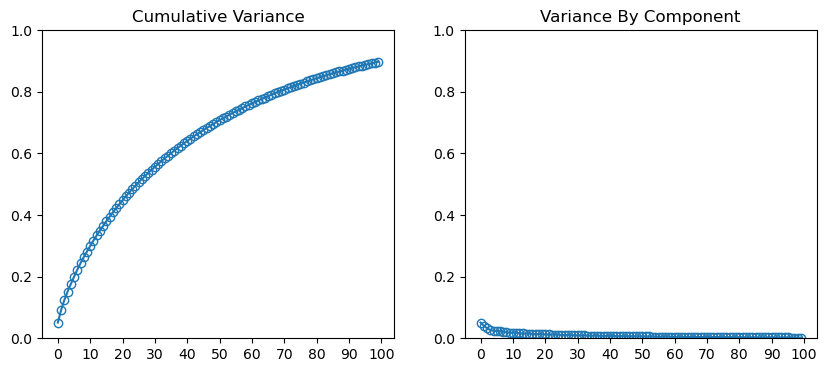

In [68]:
p, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(np.cumsum(pca.explained_variance_ratio_), marker="o", markerfacecolor="none")
axes[0].set_ylim((0, 1))
axes[0].set_title("Cumulative Variance")
_ = axes[0].set_xticks(np.arange(0, 105, 10))


axes[1].plot(pca.explained_variance_ratio_, marker="o", markerfacecolor="none")
axes[1].set_ylim((0, 1))
axes[1].set_title("Variance By Component")
_ = axes[1].set_xticks(np.arange(0, 105, 10))

In [70]:
def predict_holdout_ooo(pid, ndim_pca):
    
    # select the data to be learned upon
    df_map = df_ooo_qs.query(f"""pid != {pid}""").copy()
    m_text_embedding =  np.vstack(df_map["embedding_all_txt"].to_numpy())
    m_ooo_embedding = df_map[colnames_dim_weights_full].to_numpy()
    
    # select the to-be predicted data
    df_predict = df_ooo_qs.query(f"""pid == {pid}""").copy()
    X_new = np.array(df_predict[colnames_dim_weights_full])
    Y_new = df_predict["embedding_all_txt"].to_numpy()[0]
    
    # project to lower-dim. space
    pca = PCA(n_components=ndim_pca)
    pca_result = pca.fit_transform(scaled_data)
    
    # learn mapping
    model = RandomForestRegressor()
    model.fit(pca_result, m_ooo_embedding)
    
    # generate predictions on hold-out data
    Y_new_scaled = z_scaler_text.transform(Y_new.reshape(1, -1))
    Y_new_pca = pca.transform(Y_new_scaled)
    ooo_pred = model.predict(Y_new_pca)
    
    # compute the metric to evaluate
    target = df_ooo_qs[["pid"] + colnames_dim_weights_full].query(f"""pid == {pid}""")[colnames_dim_weights_full].to_numpy()
    diff = ooo_pred - target
    diff_abs = np.abs(diff).sum(axis=1)

    pred_heuristic = df_ooo_qs[colnames_dim_weights_full].mean(axis=0).to_numpy()
    diff_heuristic = pred_heuristic - target
    diff_abs_heuristic = np.abs(diff_heuristic).sum(axis=1)
    
    df_pred = pd.DataFrame({
        "pid": pid,
        "true": target.reshape(-1),
        **{f"ooo_pred_{i}": o for i, o in enumerate(ooo_pred)}
    }).reset_index().rename(columns={"index":"Dimension"})

    return df_pred, diff_abs, diff_abs_heuristic

In [71]:
pid = 1
ndim_pca = 30
ooo_pred, diff_abs, diff_abs_heuristic = predict_holdout_ooo(pid, ndim_pca)

In [72]:
use_filter = [i not in [82, 148] for i in l_pids_new]

In [73]:
l_pids_new_filtered = [idx for idx, filt in zip(l_pids_new, use_filter) if filt]

In [74]:
def extract_diff(x):
    return x[1]

def extract_diff_heuristic(x):
    return x[2]
    
def pipe_loo_pca(ndim_pca):  
    partial_predict = partial(predict_holdout_ooo, ndim_pca=ndim_pca)
    l_results = list(map(partial_predict, l_pids_new_filtered))
    l_diffs = list(map(extract_diff, l_results))
    l_diffs_heuristic = list(map(extract_diff_heuristic, l_results))
    df_compare = pd.DataFrame({"ndim_pca":ndim_pca, "diff":np.array(l_diffs).reshape(-1), "diff_heuristic":np.array(l_diffs_heuristic).reshape(-1)})
    df_out = df_compare.groupby("ndim_pca").mean()

    return df_out

In [75]:
l_pca_dims = [10, 30, 50, 70, 90]

In [76]:
from concurrent.futures import ThreadPoolExecutor

with ThreadPoolExecutor(os.cpu_count() - 2) as executor:
    l_results_loo_pca = list(executor.map(pipe_loo_pca, l_pca_dims))

In [85]:
df_compare = reduce(lambda x, y: pd.concat([x, y]), l_results_loo_pca)

In [86]:
df_compare.to_pickle("data/dataframes-plotting-ms/text-weights-mapping.pkl")

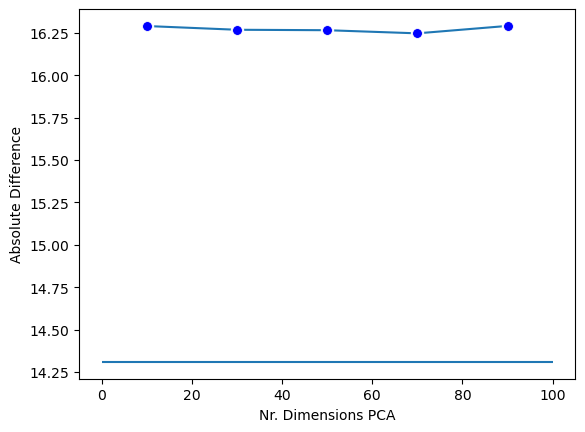

In [87]:
fig, ax = plt.subplots(1)

sns.lineplot(data=df_compare.reset_index(), x="ndim_pca", y="diff", ax=ax, zorder=1)
sns.scatterplot(data=df_compare.reset_index(), x="ndim_pca", y="diff", ax=ax, color='white', s=80, zorder=2)
sns.scatterplot(data=df_compare.reset_index(), x="ndim_pca", y="diff", ax=ax, color='blue', s=50, zorder=3)
ax.set_xlabel("Nr. Dimensions PCA")
ax.set_ylabel("Absolute Difference")
_ = ax.hlines(y=df_compare.iloc[0, 1], xmin=0, xmax=100)